# Athec - Computational Aesthetic Analysis
### Jessica Tuleassi, Wenwen Cao, Ruiheng Sun

In this demo, we will be covering the following basics about Athec:

1. Introduction
2. Basic image operations
3. Basic color features

# Introduction

# Install required packages

ATHEC is a Python package for computational aesthetic analysis of visual media.
It extracts measurable attributes such as brightness, contrast, colorfulness,
visual complexity, and depth of field.

In this tutorial, we analyze a set of images and explore how aesthetic
features differ across them.

In [ ]:
!pip install athec

Pillow is a Python library used for:

Opening, reading, editing, and saving image files.

It is the modern version of the older Python Imaging Library (PIL). It lets you:
Open image files (JPG, PNG, etc.)

Resize, Crop, Rotate images, Convert image formats, Access pixel data, Adjust brightness or contrast, Save edited images etc.

Before analyzing images in ATHEC, images need to be loaded into memomy, converted to RGB, resized, and reprocessed.

In [ ]:
!pip install requests pillow

We clone the ATHEC repository from GitHub (using !git clone) to access the source code and install the package in our Colab environment. This copies the entire ATHEC GitHub repository into our Colab environment.

In [ ]:
!git clone https://github.com/yilangpeng/athec.git

Cloning into 'athec'...
remote: Enumerating objects: 104, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 104 (delta 4), reused 0 (delta 0), pack-reused 90 (from 1)
Receiving objects: 100% (104/104), 3.81 MiB | 33.65 MiB/s, done.
Resolving deltas: 100% (39/39), done.


We append the cloned ATHEC directory to Python’s system path so that Python can locate and import the module. After copying the GitHub repository into the Colab environment, it creates a folder called "/content/athec". The sys.path.append tells Python to also look inside /content/athec when searching for modules to import. This function works when you clone the repository manually.

In [ ]:
import sys
sys.path.append("/content/athec")

In [ ]:
# install required packages for Athec (according to its Github repo). This command:
#Installs all the Python libraries that ATHEC depends on in order to work.

!pip install numpy Pillow matplotlib opencv-contrib-python scipy scikit-image pyemd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.4 MB/s eta 0:00:00


1. Numpy is used for numerical computation, working with arrays and  item matrix math. Since images are stored as matrices of pixel values, NumPY handles the mathematical aspect of the image.
2. Matplotlib is used for plotting graphs and visualizing results (e.g., color histogram).
3. OpenCV is used for advanced image processing, edge detection, blur detection and feature extraction. Many aesthetic features (like sharpness, depth of field, complexity) rely on computer vision techniques from OpenCV.
4. SciPy is used to compute certain mathematical metrics (like distribution, filtering, etc).
5. Scikit-Image is used to compute visual complexity and structural features. Can be used for imapge processing tools, texture analysis, and structural measurement.
6. PyEMD is used for measuring the distance between two distributions, usually known as Earth Mover’s Distance (EMD). ATHEC uses this for color distribution comparison and measuring color diversity or visual similarity.

Simply put, ATHEC relies on several external libraries for numerical computation (NumPy), image handling (Pillow), computer vision operations (OpenCV, scikit-image), scientific computation (SciPy), distribution comparison (PyEMD), and visualization (Matplotlib). These dependencies enable ATHEC to compute a variety of aesthetic features from images.


In [ ]:
#import required packages
from PIL import Image, ImageFilter
import numpy as np
import cv2
import webcolors
import base64
import os, sys
import matplotlib.pyplot as plt
import requests
import io
import json

# import package used for online image loading
import requests
from io import BytesIO

# import package for plotting
import matplotlib.pyplot as plt

--------------------------------------------------------------------

# BASIC IMAGE OPERATIONS

### Read an image

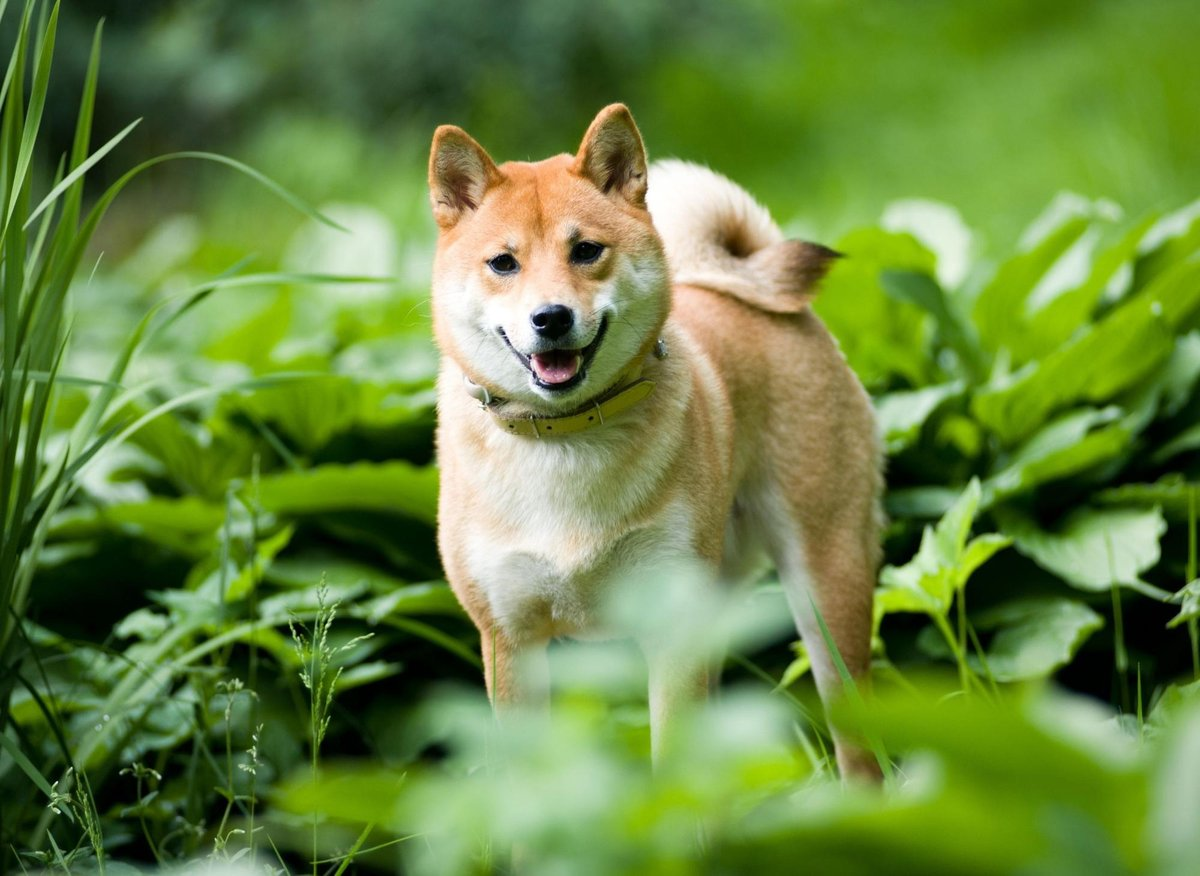

In [ ]:
response = requests.get("https://raw.githubusercontent.com/WenwenCaoUMN/JOUR8500_W7_Demo/main/dog.jpeg") # access to an image from github

img = Image.open(BytesIO(response.content)).convert("RGB") # convert the image to the "RGB" mode, regardless of its original mode

img

You can also use other packages like skimage.io.imread (skimage) or cv2 to read an image, but keep in mind that their ***default color channels can be different*** (e.g., RGB for PIL while BGR for cv2)

In [ ]:
# Convert the image object into a NumPy array
img_array = np.array(img)
img_array

array([[[ 91, 129,  72],
        [127, 165, 108],
        [134, 171, 119],
        ...,
        [ 87, 132,  41],
        [ 87, 132,  41],
        [ 87, 132,  41]],

       [[ 97, 135,  78],
        [129, 166, 112],
        [136, 173, 121],
        ...,
        [ 87, 132,  41],
        [ 87, 132,  41],
        [ 87, 132,  41]],

       [[108, 145,  91],
        [132, 169, 115],
        [139, 176, 124],
        ...,
        [ 87, 132,  39],
        [ 87, 132,  39],
        [ 87, 132,  39]],

       ...,

       [[  2,  16,   3],
        [  3,  17,   2],
        [  4,  21,   3],
        ...,
        [123, 164, 106],
        [125, 164, 107],
        [125, 164, 107]],

       [[  1,  15,   2],
        [  4,  18,   3],
        [  8,  22,   5],
        ...,
        [123, 164, 106],
        [125, 164, 107],
        [125, 164, 107]],

       [[  1,  15,   2],
        [  4,  18,   3],
        [  8,  22,   5],
        ...,
        [123, 164, 106],
        [125, 164, 107],
        [125, 164, 107]]

The way computers interpret images is by treating them as ***arrays of numerical pixel values***. Each pixel represents a specific color, which is formed by combining three primary colors: red, green, and blue. Each of these colors is assigned a decimal value, ranging from 0 to 255. A value of 0 indicates complete blackness, while 255 represents pure white. Consequently, every color pixel can be described using three numbers, known as RGB decimal values.
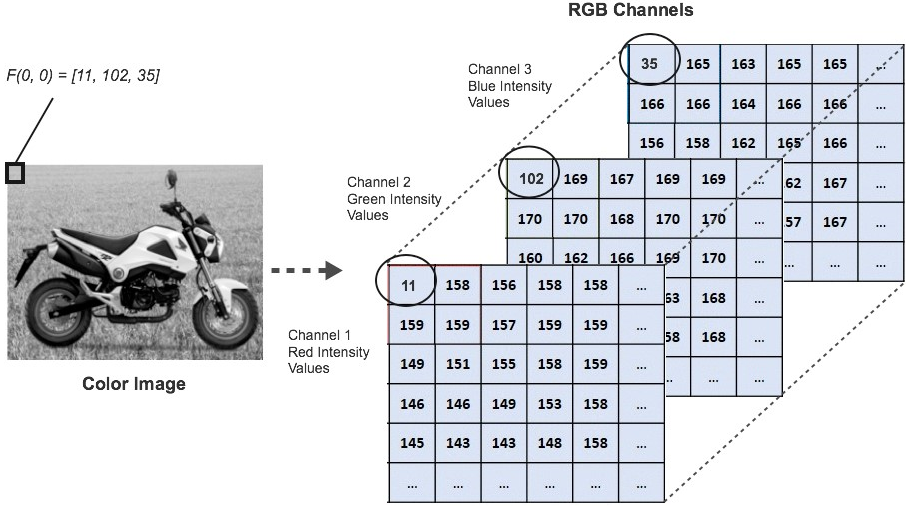

In [ ]:
# Print the shape of the Numpy array
img_array.shape #height of 876 pixels, width of 1200 pixels, and 3 color channels

(876, 1200, 3)

In [ ]:
# You can check our image's top-left pixel's RGB values
img_array[0, 0]
# In the dog picture, the top-left pixel has an RGB values of (91, 129. 72)

array([ 91, 129,  72], dtype=uint8)

# COLOR

Among all objective features of an image, the color feature is the most widely explored feature in the literature of information science, communication, psychology, and advertising. Color is the result of interaction between physical light in the environment and our visual system, and we can understand the color features of an image using different descriptors.

**<span style="font-size: larger;">Color space</span>**, also known as the color model (or color system), is an abstract mathematical model which describes the range of colors as tuples of numbers, typically as 3 or 4 values or color components. A colored image can be described with different color spaces. The RGB color space, for example, uses different combinations of red (R), green (G), and blue (B) to reproduce a broad range of colors. Each pixel uses three numbers that range from 0 to 255 to indicate red, green, and blue, respectively. For example, rgb(255, 0, 0) is displayed as red, because red is set to its highest value (255), and the other two (green and blue) are set to 0. In a grayscale image, each pixel is a single number that represents different shades of gray, typically ranging from 0 (black) to 255 (white)
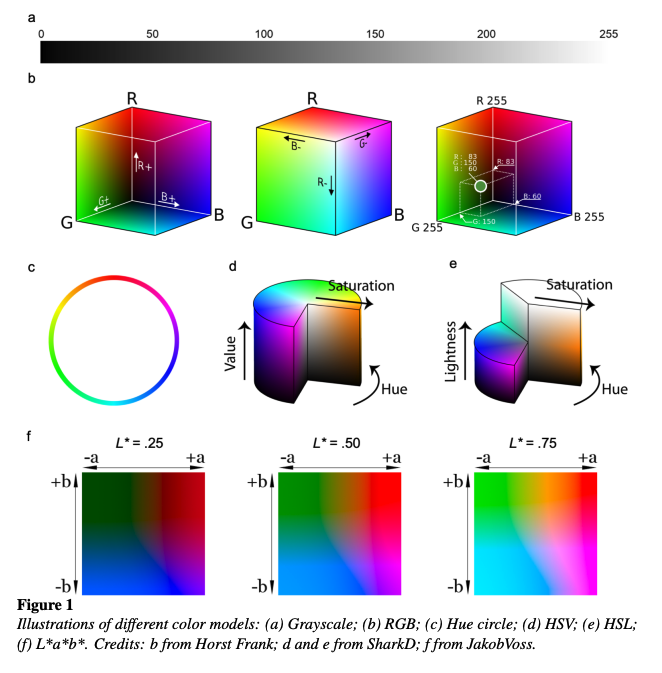



The color space is useful as we can extract specific values (e.g., brightness) from the color space. These specific values are important descriptors of an image. In social science research using images as data, many studies have found that these descriptors can be influencing human perceptions.

#### Understanding Athec Color Features

Athec extracts a wide variety of color-related descriptors.
Today we illustrate two images and compute:

*   RGB / HSV / HSL / Lab channel statistics
*   Colorfulness
*   Contrast
*   Hue count
*   Percentage of 11 canonical colors
*   Color variety metrics


These features come from prior work in computer vision and psychology (e.g., Hasler & Suesstrunk, 2003; Ke et al., 2006).

In [ ]:
#import necessary packages for processing colors of image
from athec import color, misc

### Specific colors

Psychological research finds that different colors may be influencing visual engagement and emotional reactions in different ways. Warm colors like reds and yellows were associated with higher content engagement on social media than cool colors like blues and greens, according to prior research on images.

We can use the ***color.attr_color_percentage*** function in the ***Athec*** package (Peng, 2022) to calculate the percentage of eleven basic colors in an image.

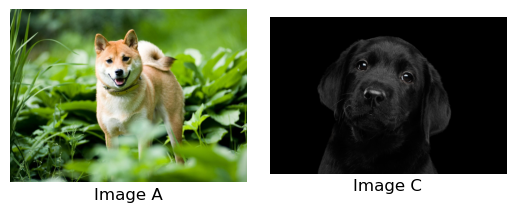

In [ ]:
# Open two images online and see how they differ
response1 = requests.get("https://raw.githubusercontent.com/WenwenCaoUMN/JOUR8500_W7_Demo/main/dog.jpeg")
image1 = Image.open(BytesIO(response1.content)).convert("RGB")

response2 = requests.get("https://raw.githubusercontent.com/WenwenCaoUMN/JOUR8500_W7_Demo/main/dog_black.jpeg")
image2 = Image.open(BytesIO(response2.content)).convert("RGB")


fig, axes = plt.subplots(1, 2)
axes[0].imshow(image1)
axes[0].axis('off')
axes[0].text(0.5, -0.1, "Image A", transform=axes[0].transAxes,
             fontsize=12, ha='center')
axes[1].imshow(image2)
axes[1].axis('off')
axes[1].text(0.5, -0.1, "Image C", transform=axes[1].transAxes,
             fontsize=12, ha='center')
plt.subplots_adjust(wspace=0.1)
plt.show()

**Q1: Please calculate the percentage of eleven basic colors**:

In [ ]:
#Covert the format from PIL.Image to numpy so that this function can deal with
color.attr_color_percentage(np.array(image1))

{'black': 0.03300894216133942,
 'blue': 0.00037290715372907153,
 'brown': 0.04683124048706241,
 'gray': 0.0033171613394216135,
 'green': 0.8369092465753425,
 'orange': 0.008891742770167427,
 'pink': 0.006832191780821918,
 'purple': 0.00015886605783866058,
 'red': 4.9467275494672755e-05,
 'white': 0.041435502283105025,
 'yellow': 0.02219273211567732,
 'color_shannon': 0.41540076100150003,
 'color_simpson': 0.17318151781070779}

**Q2: Please calculate the percentage of eleven basic colors**

In [ ]:
color.attr_color_percentage(np.array(image2))

{'black': 0.9901822916666667,
 'blue': 0.00014791666666666667,
 'brown': 5.4166666666666664e-05,
 'gray': 0.009416666666666667,
 'green': 6.25e-06,
 'orange': 0,
 'pink': 0,
 'purple': 3.125e-06,
 'red': 0,
 'white': 0.00018958333333333332,
 'yellow': 0,
 'color_shannon': 0.7652330271847139,
 'color_simpson': 0.4439806838312018}

### Other color features

Athec also enables us to compute other color descriptors and features (including brightness, contrast, etc.). See more in Peng (2022): https://www.aup-online.com/content/journals/10.5117/CCR2022.1.009.PENG

**Q3: Try to write a function to compute low-level features of an image**

In [ ]:
# Write a function to compute low-level features of an image
def color_dict(img_name):

    result = {}

    """
    Calculate summary statistics of RGB channels.
    """
    result_1 = color.attr_RGB(img_name, return_full = False)
    result.update(result_1)

    """
    Calculate summary statistics of HSV channels.
    """
    result_2 = color.attr_HSV(img_name, return_full = False)
    result.update(result_2)

    """
    Calculate summary statistics of HSL channels.
    """
    result_3 = color.attr_HSL(img_name,return_full = False)
    result.update(result_3)

    """
    Calculate summary statistics of XYZ channels
    """
    result_4 = color.attr_XYZ(img_name,return_full = False)
    result.update(result_4)

    """
    Calculate summary statistics of Lab channels
    """
    result_5 = color.attr_Lab(img_name,return_full = False)
    result.update(result_5)

    """
    Calculate summary statistics of grayscale channel
    """
    result_6 = color.attr_grayscale(img_name,return_full = False)
    result.update(result_6)

    """
    Calculate contrast based on a range that covers a certain percentage of the brightness histogram.
    Return the range and its lower and upper limits.
    save_path (optional, default None): str. If provided, a visualization will be saved to this location.
    threshold (optional, default 0.9): float. The percentage the range covers.
    """
    result_7 = color.attr_contrast_range(img_name,threshold = 0.90)
    result.update(result_7)

    """
    Calculate contrast based on peak detection on the brightness histogram.
    """
    result_8 = color.attr_contrast_peak(img_name,
                                  savgol_filter_window_length = 51,
                                  savgol_filter_polyorder = 5,
                                  savgol_filter_mode = "constant",
                                  argrelmax_order = 20)
    result.update(result_8)

    """
    Calculate colorfulness based on the formula in Hasler and Suesstrunk (2003)
    """
    result_9 = color.attr_colorful(img_name)
    result.update(result_9)

    """
    Calculate colorfulness based on the distance between two color distributions (Datta et al., 2006)
    """
    result_10 = color.attr_colorful_emd(img_name)
    result.update(result_10)

    """
    Calculate percentages of eleven specific colors and color variety measures based on color percentages (excluding black, white, and gray).
    color_dict (optional, default None): if not provided, the function will automatically import the dictionary using colordict.color_dict().
    save_path (optional, default None): str. If provided, a visualization will be saved to this location.
    """
    result_11 = color.attr_color_percentage(img_name)
    result.update(result_11)

    """
    Calculate color variety based on hue count formula in Ke et al. (2006).
    save_path (optional, default None): str. If provided, a visualization will be saved to this location.
    saturation_low (optional, default 0.2): float. The lower limit for saturation. Pixels with saturation below the limit are discarded.
    value_low (optional, default 0.15): float. The lower limit for value. Pixels with value below the limit are discarded.
    value_high (optional, default 0.95): float. The upper limit for value. Pixels with value above the limit are discarded.
    hue_count_alpha (optional, default 0.05): float. Alpha in the hue count formula.
    """
    result_12 = color.attr_hue_count(img_name,
                              saturation_low = 0.2,
                              value_low = 0.15,
                              value_high = 0.95,
                              hue_count_alpha = 0.05)
    result.update(result_12)

    return result

**Q4: Try to apply the function you wrote before for both image**

In [ ]:
color_dict(np.array(image1))

{'RGB_R_mean': 104.83219558599696,
 'RGB_R_std_dev': 59.653873194558216,
 'RGB_G_mean': 64.6208247716895,
 'RGB_G_std_dev': 62.26057242994583,
 'RGB_B_mean': 133.35370814307458,
 'RGB_B_std_dev': 57.79401103995823,
 'HSV_H_mean': 44.76789668949772,
 'HSV_H_std_dev': 13.465925230843231,
 'HSV_S_mean': 152.39102739726027,
 'HSV_S_std_dev': 74.92063903057442,
 'HSV_V_mean': 135.88221461187214,
 'HSV_V_std_dev': 59.46957069418437,
 'HSV_H_circular_mean': 44.65830556958143,
 'HSV_H_circular_std_dev': 12.614219263578397,
 'HSL_H_mean': 44.75298040334855,
 'HSL_H_std_dev': 13.456999494330354,
 'HSL_S_mean': 138.89776921613395,
 'HSL_S_std_dev': 73.37070108789086,
 'HSL_L_mean': 100.1892151826484,
 'HSL_L_std_dev': 56.90706329002597,
 'HSL_H_circular_mean': 44.64403674053008,
 'HSL_H_circular_std_dev': 12.605384671331661,
 'XYZ_X_mean': 102.58372241248098,
 'XYZ_X_std_dev': 53.83821699219424,
 'XYZ_Y_mean': 122.32973744292238,
 'XYZ_Y_std_dev': 56.78026691055042,
 'XYZ_Z_mean': 79.213663432267

In [ ]:
color_dict(np.array(image2))

{'RGB_R_mean': 9.745367708333333,
 'RGB_R_std_dev': 18.75933525664064,
 'RGB_G_mean': 9.722428125,
 'RGB_G_std_dev': 18.75909592426766,
 'RGB_B_mean': 9.725205208333334,
 'RGB_B_std_dev': 18.746399190621638,
 'HSV_H_mean': 0.9082135416666667,
 'HSV_H_std_dev': 10.974407692645658,
 'HSV_S_mean': 0.5186458333333334,
 'HSV_S_std_dev': 6.98536477808419,
 'HSV_V_mean': 9.762172916666668,
 'HSV_V_std_dev': 18.83798043921994,
 'HSV_H_circular_mean': 0.02373990642178914,
 'HSV_H_circular_std_dev': 2.937836536470725,
 'HSL_H_mean': 0.9079739583333334,
 'HSL_H_std_dev': 10.971041282971044,
 'HSL_S_mean': 0.34485,
 'HSL_S_std_dev': 5.649841935325858,
 'HSL_L_mean': 9.733634375,
 'HSL_L_std_dev': 18.756583410334045,
 'HSL_H_circular_mean': 0.0235841720284085,
 'HSL_H_circular_std_dev': 2.938366237402207,
 'XYZ_X_mean': 9.277391666666666,
 'XYZ_X_std_dev': 17.816483347261997,
 'XYZ_Y_mean': 9.728183333333334,
 'XYZ_Y_std_dev': 18.74794625062673,
 'XYZ_Z_mean': 10.57131875,
 'XYZ_Z_std_dev': 20.4247